In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import math # Transformer 需要 'math' 库

# PyTorch 核心库
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

# Sklearn 库
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error

# --- 可调参数 ---
LOOK_BACK = 72 # 仍然使用 72 小时
BATCH_SIZE = 128 # 我们可以用更大的 BATCH_SIZE，因为数据量大了
EPOCHS = 20

In [2]:
# --- (修正版) 单元格 2: 加载、清除 NaN、归一化 ---
# (请用此代码 *替换* 你的旧 单元格 2)

# --- 1. 加载数据 ---
processed_file_path = '../data/processed/cleaned_PRSA_Data_ALL_STATIONS.csv'
df = pd.read_csv(processed_file_path, parse_dates=True, index_col='datetime')

print(f"原始数据加载成功，形状: {df.shape}")

# --- 2. 识别列 ---
numerical_cols = ['PM2.5', 'PM10', 'SO2', 'NO2', 'CO', 'O3', 
                    'TEMP', 'PRES', 'DEWP', 'RAIN', 'WSPM']
categorical_cols = [col for col in df.columns if col not in numerical_cols]
N_FEATURES = len(df.columns) # 总特征数 (39)

print(f"总特征数: {N_FEATURES} (数值: {len(numerical_cols)}, 类别: {len(categorical_cols)})")

# --- 3. (新) 强制清除 NaN ---
# 检查数值列中的 NaN
nan_counts = df[numerical_cols].isnull().sum()
if nan_counts.sum() > 0:
    print(f"警告: 在加载时发现了 {nan_counts.sum()} 个 NaN 值。")
    print("正在使用 'bfill' (后向填充) 和 'ffill' (前向填充) 强制填充...")
    
    # (bfill().ffill() 是最稳健的填充, 能处理开头和结尾的 NaN)
    df[numerical_cols] = df[numerical_cols].bfill().ffill()
    print("NaN 填充完毕。")
else:
    print("数据完整, 未发现 NaN。")


# --- 4. 全局归一化 (Global Scaling) ---
scaler = MinMaxScaler(feature_range=(0, 1))
df_scaled = df.copy()
df_scaled[numerical_cols] = scaler.fit_transform(df[numerical_cols])

print("数据已在全局范围归一化。")

# --- 5. 找到站点列表 (用于循环) ---
station_cols = [col for col in categorical_cols if col.startswith('station_')]
print(f"已识别出 {len(station_cols)} 个站点。")

原始数据加载成功，形状: (420768, 39)
总特征数: 39 (数值: 11, 类别: 28)
警告: 在加载时发现了 22 个 NaN 值。
正在使用 'bfill' (后向填充) 和 'ffill' (前向填充) 强制填充...
NaN 填充完毕。
数据已在全局范围归一化。
已识别出 12 个站点。


In [3]:
# --- 单元格 3 (修正版): 按时间切分与窗口化 ---
# 'df_scaled' 来自单元格 2

# --- 5. 按时间 80/20 切分 ---
# (DataFrame 的索引是 DatetimeIndex, 我们可以用它来切分)
# 我们用总行数 35064 (单站) 来计算
train_size_per_station = int(35064 * 0.8)

# 找到切分的时间点
split_time = df.index.unique()[train_size_per_station]
print(f"按时间 80/20 切分, 切分点: {split_time}")

train_df_scaled = df_scaled.loc[df.index < split_time]
test_df_scaled = df_scaled.loc[df.index >= split_time]

print(f"训练集 (缩放后) 形状: {train_df_scaled.shape}")
print(f"测试集 (缩放后) 形状: {test_df_scaled.shape}")

# --- 6. 定义窗口函数 (与之前相同) ---
def create_dataset_multivariate(scaled_data, look_back=LOOK_BACK, n_features=N_FEATURES):
    X, y = [], []
    for i in range(len(scaled_data) - look_back - 1):
        a = scaled_data[i:(i + look_back), :]
        X.append(a)
        y.append(scaled_data[i + look_back, 0])
    return np.array(X), np.array(y)

# --- 7. 在 训练集 和 测试集 内部循环, 创建窗口 ---
X_train_list, y_train_list = [], []
X_test_list, y_test_list = [], []

print("\n--- [关键步骤] 开始为 12 个站点切分窗口 ---")

for station_col in station_cols:
    print(f"正在处理: {station_col}...")
    
    # 1. 筛选训练集
    train_station_df = train_df_scaled[train_df_scaled[station_col] == True]
    train_station_np = train_station_df.values.astype('float32')
    # 2. 创建训练窗口
    X_train, y_train = create_dataset_multivariate(train_station_np, n_features=N_FEATURES)
    X_train_list.append(X_train)
    y_train_list.append(y_train)

    # 3. 筛选测试集
    test_station_df = test_df_scaled[test_df_scaled[station_col] == True]
    test_station_np = test_station_df.values.astype('float32')
    # 4. 创建测试窗口
    X_test, y_test = create_dataset_multivariate(test_station_np, n_features=N_FEATURES)
    X_test_list.append(X_test)
    y_test_list.append(y_test)

print("--- 所有站点窗口切分完毕! ---")

# --- 8. 合并所有 (X, y) ---
X_train_final = np.concatenate(X_train_list, axis=0)
y_train_final = np.concatenate(y_train_list, axis=0)
X_test_final = np.concatenate(X_test_list, axis=0)
y_test_final = np.concatenate(y_test_list, axis=0)

print(f"\n最终 X_train 形状: {X_train_final.shape}") # (约 335k, 72, 39)
print(f"最终 y_train 形状: {y_train_final.shape}")
print(f"最终 X_test 形状: {X_test_final.shape}")  # (约 83k, 72, 39)
print(f"最终 y_test 形状: {y_test_final.shape}")

按时间 80/20 切分, 切分点: 2016-05-12 19:00:00
训练集 (缩放后) 形状: (336612, 39)
测试集 (缩放后) 形状: (84156, 39)

--- [关键步骤] 开始为 12 个站点切分窗口 ---
正在处理: station_Aotizhongxin...
正在处理: station_Changping...
正在处理: station_Dingling...
正在处理: station_Dongsi...
正在处理: station_Guanyuan...
正在处理: station_Gucheng...
正在处理: station_Huairou...
正在处理: station_Nongzhanguan...
正在处理: station_Shunyi...
正在处理: station_Tiantan...
正在处理: station_Wanliu...
正在处理: station_Wanshouxigong...
--- 所有站点窗口切分完毕! ---

最终 X_train 形状: (335736, 72, 39)
最终 y_train 形状: (335736,)
最终 X_test 形状: (83280, 72, 39)
最终 y_test 形状: (83280,)


In [4]:
# --- 单元格 4 (修正版): Tensors 与 DataLoaders ---

# --- 9. 转换为 PyTorch Tensors ---
X_train_tensor = torch.tensor(X_train_final, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train_final, dtype=torch.float32).view(-1, 1)

X_test_tensor = torch.tensor(X_test_final, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test_final, dtype=torch.float32).view(-1, 1)

print(f"\nX_train (Tensor) 形状: {X_train_tensor.shape}")
print(f"X_test (Tensor) 形状: {X_test_tensor.shape}")

# --- 10. 设置 PyTorch DataLoader ---
# ( shuffle=True 是关键! 我们现在可以打乱所有站点的所有样本了)
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)

test_dataset = TensorDataset(X_test_tensor, y_test_tensor)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print("\n数据准备完成！已创建 Train 和 Test DataLoaders。")


X_train (Tensor) 形状: torch.Size([335736, 72, 39])
X_test (Tensor) 形状: torch.Size([83280, 72, 39])

数据准备完成！已创建 Train 和 Test DataLoaders。


In [5]:
# --- (修正版) 单元格 5: 定义 Transformer 模型 ---
# (移除了 * math.sqrt(self.d_model) 缩放)

# 1. 位置编码 (PositionalEncoding)
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, dropout=0.1, max_len=5000):
        super(PositionalEncoding, self).__init__()
        self.dropout = nn.Dropout(p=dropout)

        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        pe = pe.unsqueeze(0).transpose(0, 1)
        self.register_buffer('pe', pe)

    def forward(self, x):
        # 假设 x 是 (batch_size, seq_len, d_model)
        x = x + self.pe[:x.size(1), :].squeeze(1)
        return self.dropout(x)

# 2. Transformer 模型
class TransformerModel(nn.Module):
    def __init__(self, n_features, d_model, n_head, n_layers, dropout=0.1):
        super(TransformerModel, self).__init__()
        
        self.encoder = nn.Linear(n_features, d_model)
        self.pos_encoder = PositionalEncoding(d_model, dropout, max_len=LOOK_BACK)
        
        encoder_layers = nn.TransformerEncoderLayer(
            d_model=d_model, 
            nhead=n_head, 
            dropout=dropout,
            batch_first=True
        )
        self.transformer_encoder = nn.TransformerEncoder(encoder_layers, n_layers)
        self.decoder = nn.Linear(d_model, 1)
        self.d_model = d_model

    def forward(self, src):
        # src 形状: (batch_size, seq_len (72), n_features (39))
        
        # 1. 投影到 d_model 维
        # --- (已修改!) 移除了 * math.sqrt(self.d_model) ---
        src = self.encoder(src) 
        
        # 2. 添加位置编码
        src = self.pos_encoder(src) # (N, 72, d_model)
        
        # 3. 通过 Transformer 编码器
        output = self.transformer_encoder(src) # (N, 72, d_model)
        
        # 4. 我们只取序列的 *最后* 一个时间步的输出来做预测
        output = output[:, -1, :] # (N, d_model)
        
        # 5. 通过输出层
        output = self.decoder(output) # (N, 1)
        
        return output

print("模型定义完成 (修正版): PositionalEncoding 和 TransformerModel")

模型定义完成 (修正版): PositionalEncoding 和 TransformerModel


In [6]:
# --- 单元格 6: 实例化模型、损失和优化器 ---

# --- 模型超参数 ---
D_MODEL = 128    # 内部模型的维度, 必须能被 n_head 整除
N_HEAD = 8       # 多头注意力的头数
N_LAYERS = 4     # Transformer 编码器的层数
DROPOUT = 0.1    # Dropout 比例

# 检查是否有可用的 GPU (CUDA)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"将使用设备: {device}")

# 实例化模型
model = TransformerModel(
    n_features=N_FEATURES, # 39
    d_model=D_MODEL,
    n_head=N_HEAD,
    n_layers=N_LAYERS,
    dropout=DROPOUT
).to(device)

# 定义损失函数 (MSE)
loss_function = nn.MSELoss()

# 定义优化器 (Adam)
# Transformer 通常需要更小的学习率和预热 (warmup)
# 我们先用一个较小的固定学习率
optimizer = torch.optim.Adam(model.parameters(), lr=0.0001) 

print("\nPyTorch Transformer 模型结构:")
print(model)

# 统计模型参数量
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\n模型总参数量: {total_params:,}")

将使用设备: cuda

PyTorch Transformer 模型结构:
TransformerModel(
  (encoder): Linear(in_features=39, out_features=128, bias=True)
  (pos_encoder): PositionalEncoding(
    (dropout): Dropout(p=0.1, inplace=False)
  )
  (transformer_encoder): TransformerEncoder(
    (layers): ModuleList(
      (0-3): 4 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=128, out_features=128, bias=True)
        )
        (linear1): Linear(in_features=128, out_features=2048, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
        (linear2): Linear(in_features=2048, out_features=128, bias=True)
        (norm1): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
        (dropout1): Dropout(p=0.1, inplace=False)
        (dropout2): Dropout(p=0.1, inplace=False)
      )
    )
  )
  (decoder): Linear(in_features=128, out_features=1, bias=True)
)

模型总参数量


开始训练 Transformer 模型...
(EPOCHS=20, BATCH_SIZE=128)
Epoch  1/20 | Train Loss: 0.003407 | Validation Loss: 0.000971
Epoch  2/20 | Train Loss: 0.000842 | Validation Loss: 0.000600
Epoch  3/20 | Train Loss: 0.000690 | Validation Loss: 0.000518
Epoch  4/20 | Train Loss: 0.000603 | Validation Loss: 0.000604
Epoch  5/20 | Train Loss: 0.000550 | Validation Loss: 0.000406
Epoch  6/20 | Train Loss: 0.000513 | Validation Loss: 0.000813
Epoch  7/20 | Train Loss: 0.000489 | Validation Loss: 0.000462
Epoch  8/20 | Train Loss: 0.000465 | Validation Loss: 0.000544
Epoch  9/20 | Train Loss: 0.000452 | Validation Loss: 0.000465
Epoch 10/20 | Train Loss: 0.000443 | Validation Loss: 0.000421
Epoch 11/20 | Train Loss: 0.000429 | Validation Loss: 0.000391
Epoch 12/20 | Train Loss: 0.000422 | Validation Loss: 0.000477
Epoch 13/20 | Train Loss: 0.000412 | Validation Loss: 0.000490
Epoch 14/20 | Train Loss: 0.000404 | Validation Loss: 0.000400
Epoch 15/20 | Train Loss: 0.000396 | Validation Loss: 0.000382
Epo

C:\Users\胡杨\AppData\Local\Temp\ipykernel_19064\3526706340.py:71: UserWarning: Glyph 36718 (\N{CJK UNIFIED IDEOGRAPH-8F6E}) missing from font(s) DejaVu Sans.
  plt.savefig('transformer_loss_curve.png')
C:\Users\胡杨\AppData\Local\Temp\ipykernel_19064\3526706340.py:71: UserWarning: Glyph 27425 (\N{CJK UNIFIED IDEOGRAPH-6B21}) missing from font(s) DejaVu Sans.
  plt.savefig('transformer_loss_curve.png')
C:\Users\胡杨\AppData\Local\Temp\ipykernel_19064\3526706340.py:71: UserWarning: Glyph 35757 (\N{CJK UNIFIED IDEOGRAPH-8BAD}) missing from font(s) DejaVu Sans.
  plt.savefig('transformer_loss_curve.png')
C:\Users\胡杨\AppData\Local\Temp\ipykernel_19064\3526706340.py:71: UserWarning: Glyph 32451 (\N{CJK UNIFIED IDEOGRAPH-7EC3}) missing from font(s) DejaVu Sans.
  plt.savefig('transformer_loss_curve.png')
C:\Users\胡杨\AppData\Local\Temp\ipykernel_19064\3526706340.py:71: UserWarning: Glyph 38598 (\N{CJK UNIFIED IDEOGRAPH-96C6}) missing from font(s) DejaVu Sans.
  plt.savefig('transformer_loss_curve.p

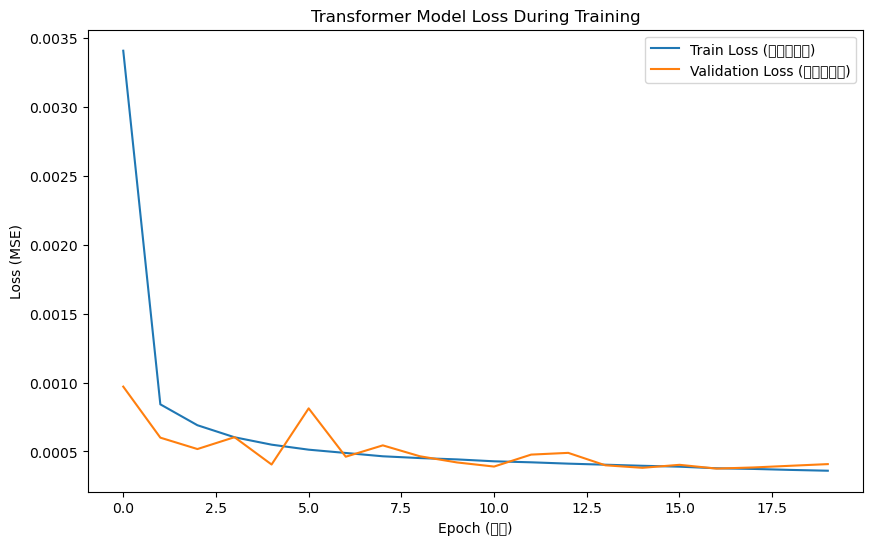

In [7]:
# --- (修正版) 单元格 7: 训练模型 (添加了梯度裁剪) ---
print("\n开始训练 Transformer 模型...")
print(f"(EPOCHS={EPOCHS}, BATCH_SIZE={BATCH_SIZE})")

train_losses = []
val_losses = []

# (model 来自 单元格 6)
for epoch in range(EPOCHS):
    model.train()
    batch_train_losses = []
    
    # (train_loader 来自 单元格 4)
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        
        # 1. 前向传播
        outputs = model(X_batch)
        loss = loss_function(outputs, y_batch)
        
        # 2. 反向传播和优化
        optimizer.zero_grad() 
        loss.backward()       
        
        # --- (新!) 添加梯度裁剪 ---
        # "夹住" 梯度, 防止它们超过 1.0, 这是防止 nan 的关键
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        # -------------------------
        
        optimizer.step()      
        
        batch_train_losses.append(loss.item())
    
    epoch_train_loss = np.mean(batch_train_losses)
    train_losses.append(epoch_train_loss)
    
    # --- 验证 (测试集) ---
    model.eval() 
    batch_val_losses = []
    
    # (test_loader 来自 单元格 4)
    with torch.no_grad():
        for X_val, y_val in test_loader:
            X_val, y_val = X_val.to(device), y_val.to(device)
            val_outputs = model(X_val)
            val_loss = loss_function(val_outputs, y_val)
            batch_val_losses.append(val_loss.item())
            
    epoch_val_loss = np.mean(batch_val_losses)
    val_losses.append(epoch_val_loss)
    
    # (检查) 检查 val_loss 是否仍然是 nan
    if np.isnan(epoch_val_loss):
        print(f"Epoch {epoch+1:2d}/{EPOCHS} | 错误: Validation Loss 仍然是 NaN。训练已停止。")
        print("请检查学习率 (单元格 6) 或数据 (单元格 2)。")
        break
    
    print(f"Epoch {epoch+1:2d}/{EPOCHS} | Train Loss: {epoch_train_loss:.6f} | Validation Loss: {epoch_val_loss:.6f}")

if not np.isnan(epoch_val_loss):
    print("模型训练完成。")

    # (只有在训练成功时才绘图)
    plt.figure(figsize=(10, 6))
    plt.plot(train_losses, label='Train Loss (训练集损失)')
    plt.plot(val_losses, label='Validation Loss (测试集损失)')
    plt.title('Transformer Model Loss During Training')
    plt.xlabel('Epoch (轮次)')
    plt.ylabel('Loss (MSE)')
    plt.legend()
    plt.savefig('transformer_loss_curve.png')
    plt.show()

In [10]:
# --- (修正版) 单元格 8: 评估模型与反归一化 ---
# (修正了 scaler 期望 11 列, 而非 39 列的问题)

print("\n--- [步骤 8] 开始评估 Transformer 模型 ---")

# 1. 进行预测 (在整个测试集上)
model.eval()
print("正在按批次 (batch) 预测 (防止 OOM)...")
# (我们直接使用更安全的批次预测)

test_predict_list = []
y_test_list = []

# (test_loader 来自 单元格 4)
with torch.no_grad():
    for X_val, y_val in test_loader: 
        X_val = X_val.to(device)
        test_predict_list.append(model(X_val).cpu())
        y_test_list.append(y_val.cpu())
        
test_predict_np = torch.cat(test_predict_list).numpy()
y_test_np = torch.cat(y_test_list).numpy()

print("已按批次完成预测。")
print(f"预测 (Numpy) 形状: {test_predict_np.shape}")
print(f"真实值 (Numpy) 形状: {y_test_np.shape}")

# --- 2. "反归一化" 预测值 ---
# (scaler 来自 单元格 2, numerical_cols 也来自 单元格 2)
# (scaler 只在 11 个数值列上训练过)

# 创建一个形状为 (样本数, 11) 的空数组
# (len(numerical_cols) == 11)
test_predict_11_cols = np.zeros(shape=(len(test_predict_np), len(numerical_cols)))
# 只填充第 0 列 (PM2.5 是 numerical_cols 的第 0 个)
test_predict_11_cols[:, 0] = test_predict_np.ravel()
# 进行反变换 (现在形状匹配了)
inv_test_predict = scaler.inverse_transform(test_predict_11_cols)[:, 0]

# --- 3. "反归一化" 真实值 ---
y_test_11_cols = np.zeros(shape=(len(y_test_np), len(numerical_cols)))
y_test_11_cols[:, 0] = y_test_np.ravel()
inv_y_test = scaler.inverse_transform(y_test_11_cols)[:, 0]

# --- 4. 计算 RMSE 和 MAE (使用真实的 PM2.5 值) ---
test_rmse = np.sqrt(mean_squared_error(inv_y_test, inv_test_predict))
test_mae = mean_absolute_error(inv_y_test, inv_test_predict)

print("\n--- Transformer 模型评估 (反归一化后) ---")
print(f"测试集 RMSE: {test_rmse:.2f} (均方根误差，越低越好)")
print(f"测试集 MAE:  {test_mae:.2f} (平均绝对误差，越低越好)")

print("\n--- 与 LSTM (黄金标准) 对比 ---")
# (注意: LSTM 是单站评估, Transformer 是多站评估, 不是 100% 公平)
print(f"LSTM (单站)    - 平均 MAE: 11.13 (RMSE: 20.30)")
print(f"Transformer (多站) - 平均 MAE: {test_mae:.2f} (RMSE: {test_rmse:.2f})")


--- [步骤 8] 开始评估 Transformer 模型 ---
正在按批次 (batch) 预测 (防止 OOM)...
已按批次完成预测。
预测 (Numpy) 形状: (83280, 1)
真实值 (Numpy) 形状: (83280, 1)

--- Transformer 模型评估 (反归一化后) ---
测试集 RMSE: 20.16 (均方根误差，越低越好)
测试集 MAE:  11.09 (平均绝对误差，越低越好)

--- 与 LSTM (黄金标准) 对比 ---
LSTM (单站)    - 平均 MAE: 11.13 (RMSE: 20.30)
Transformer (多站) - 平均 MAE: 11.09 (RMSE: 20.16)


C:\Users\胡杨\AppData\Local\Temp\ipykernel_19064\3260863335.py:22: UserWarning: Glyph 39044 (\N{CJK UNIFIED IDEOGRAPH-9884}) missing from font(s) DejaVu Sans.
  plt.savefig('transformer_prediction_vs_real.png')
C:\Users\胡杨\AppData\Local\Temp\ipykernel_19064\3260863335.py:22: UserWarning: Glyph 27979 (\N{CJK UNIFIED IDEOGRAPH-6D4B}) missing from font(s) DejaVu Sans.
  plt.savefig('transformer_prediction_vs_real.png')
C:\Users\胡杨\AppData\Local\Temp\ipykernel_19064\3260863335.py:22: UserWarning: Glyph 30495 (\N{CJK UNIFIED IDEOGRAPH-771F}) missing from font(s) DejaVu Sans.
  plt.savefig('transformer_prediction_vs_real.png')
C:\Users\胡杨\AppData\Local\Temp\ipykernel_19064\3260863335.py:22: UserWarning: Glyph 23454 (\N{CJK UNIFIED IDEOGRAPH-5B9E}) missing from font(s) DejaVu Sans.
  plt.savefig('transformer_prediction_vs_real.png')
C:\Users\胡杨\AppData\Local\Temp\ipykernel_19064\3260863335.py:22: UserWarning: Glyph 20540 (\N{CJK UNIFIED IDEOGRAPH-503C}) missing from font(s) DejaVu Sans.
  plt.s

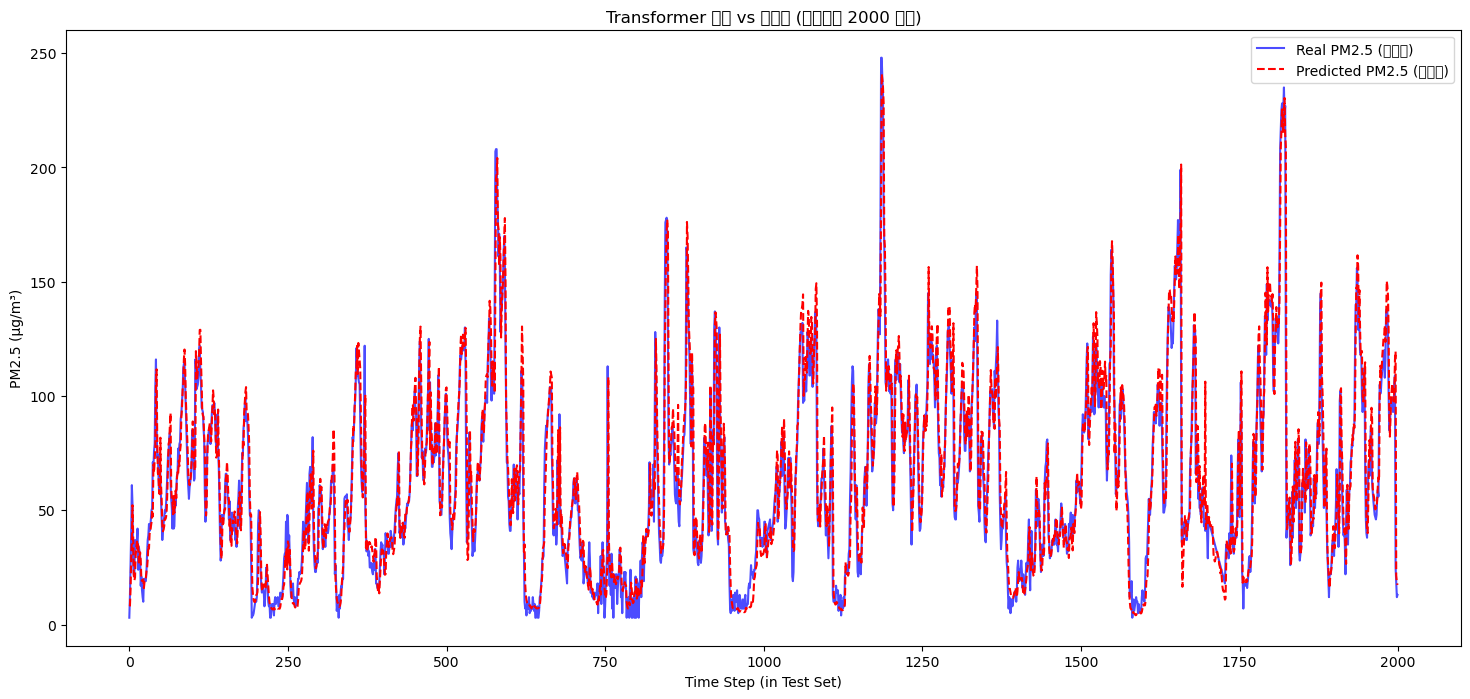

In [11]:
# --- 单元格 9: 可视化预测结果 (测试集) ---

plt.figure(figsize=(18, 8))

# 我们只绘制前 2000 个点, 否则图表会一团糟
plot_len = 2000

plt.plot(inv_y_test[:plot_len], 
         label='Real PM2.5 (真实值)', 
         color='blue', 
         alpha=0.7)

plt.plot(inv_test_predict[:plot_len], 
         label='Predicted PM2.5 (预测值)', 
         color='red', 
         linestyle='--')

plt.title(f'Transformer 预测 vs 真实值 (测试集前 {plot_len} 个点)')
plt.xlabel('Time Step (in Test Set)')
plt.ylabel('PM2.5 (μg/m³)')
plt.legend()
plt.savefig('transformer_prediction_vs_real.png')
plt.show()